# 3 · Planning in the real game: three pieces per round

In the 3P game, the order in which the three pieces are played matters. We use
the DVN trained on the **1-piece** game as a heuristic inside a short search:

$$\text{score}(a_0) = r_0 + \gamma \max_{a_1}\big[r_1 + \gamma\, V_\theta(s_2)\big] \qquad \text{(depth 2)}$$

The agent replans after every placement. The baseline **greedy depth-k** does
the same exhaustive search but only sums immediate rewards (no value network).

In [1]:
# `uv sync` installs the project; this line only lets the notebook run without it.
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(4)
%matplotlib inline

In [2]:
from blockblast import BlockBlast3PEnv
from common.evaluation import run_episodes, print_table
from common.plotting import plot_distributions
from common.policies import GreedyLookahead3P, RandomPolicy
from dvn.agent import load_dvn_agent
from dvn.lookahead import DVNLookahead3P

dvn = load_dvn_agent("../final_weights/dvn_final_20260313_020137.pt")

## Benchmark (small, CPU-friendly)

30 seeded episodes per policy, capped at 300 placements, all policies on the
same piece sequences. The report uses 250 episodes and 1,000 placements (see
the table below): here the cap truncates the best DVN games, so its mean is
underestimated.

In [3]:
N_EPISODES, MAX_STEPS = 30, 300
policies = {
    "DVN depth-2": DVNLookahead3P(dvn, depth=2),
    "Greedy depth-2": GreedyLookahead3P(depth=2),
    "Greedy depth-1": GreedyLookahead3P(depth=1),
    "Random": RandomPolicy(0),
}
results = {name: run_episodes(BlockBlast3PEnv(), pol, N_EPISODES, seed=0, max_steps=MAX_STEPS, progress=False)
           for name, pol in policies.items()}
print_table(results, f"BlockBlast 3P, {N_EPISODES} episodes, {MAX_STEPS} steps max")


  BlockBlast 3P, 30 episodes, 300 steps max
policy                    n    mean ret     ± sem     median  mean len  ms/dec
------------------------------------------------------------------------------
DVN depth-2              30     13431.9    1926.5    11385.7     173.5    39.4
Greedy depth-2           30      2000.2     418.1      877.1      45.8    15.4
Greedy depth-1           30       661.9     107.5      497.0      34.3     0.5
Random                   30        20.8       5.1       11.0      11.8     0.0


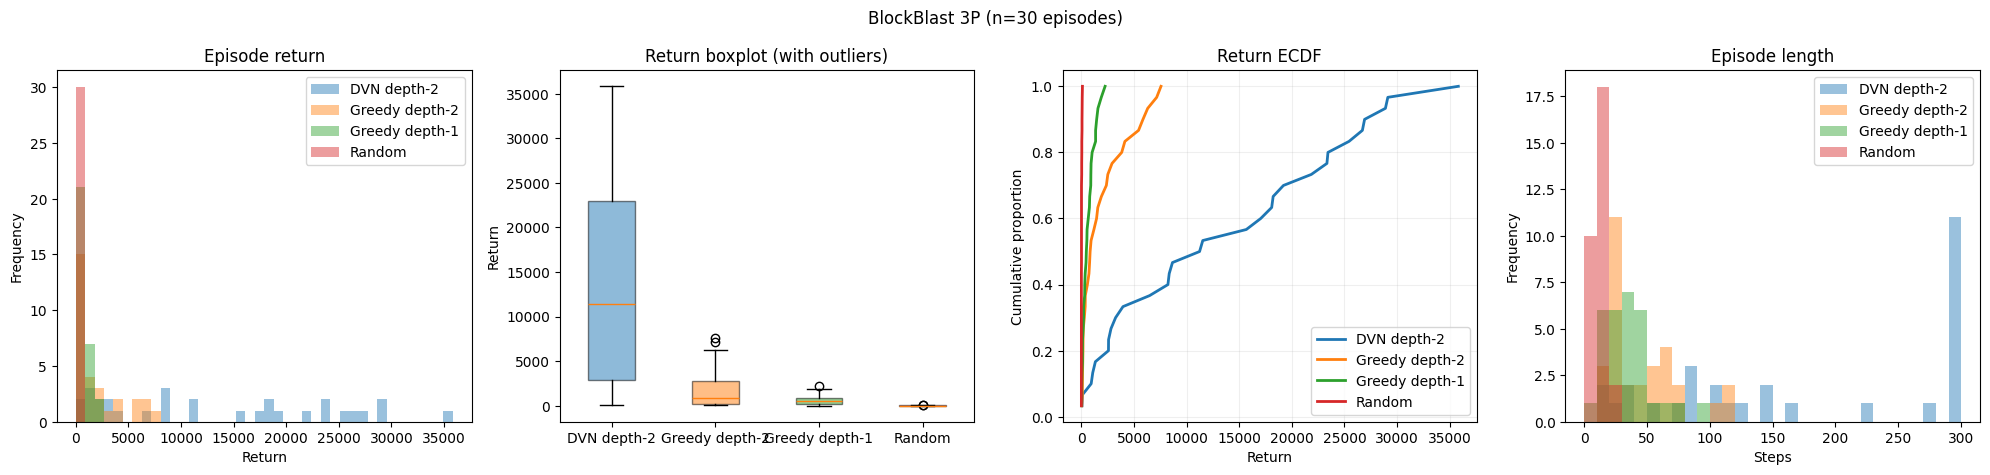

In [4]:
plot_distributions(results, title="BlockBlast 3P");

**Results reported in the paper** (250 episodes, γ = 0.99, 1,000 steps max;
depth-3: 25 episodes only, so its mean is very uncertain):

| Policy | Mean return | Mean length |
|---|---:|---:|
| DVN depth-3 | 47,469 | 224 |
| DVN depth-2 | 23,413 | 209 |
| Greedy depth-2 | 1,885 | 44 |
| Random | 25 | 12 |

Greedy clears lines as soon as possible and fragments the board. The DVN gives
up immediate points to keep the board playable, and survives ~5× longer.

Reproduce with:
```bash
python -m dvn.benchmark_3p --checkpoint final_weights/dvn_final_20260313_020137.pt \
    --policies dvn-d2 greedy-d2 random --episodes 250
```

## PPO + exhaustive round search

We also trained a PPO actor-critic (~880k parameters) on the 3P game for 43M
steps. The policy alone plays ~25 placements. Using its critic to score every
3-placement sequence of a round ("MCTS Full Triplet", which is in fact an exhaustive
search) gives the best agent of the project:

$$\text{score} = \text{symlog}(r_t + \gamma r_{t+1} + \gamma^2 r_{t+2}) + \alpha\, \text{symlog}\,V_\phi(s_{t+3})$$

The PPO checkpoint is too large to be versioned, so this section shows the
figures of the report. Reproduce with `python -m ppo.train`, `python -m ppo.value_weight_sweep`
and `python -m ppo.benchmark_3p`.

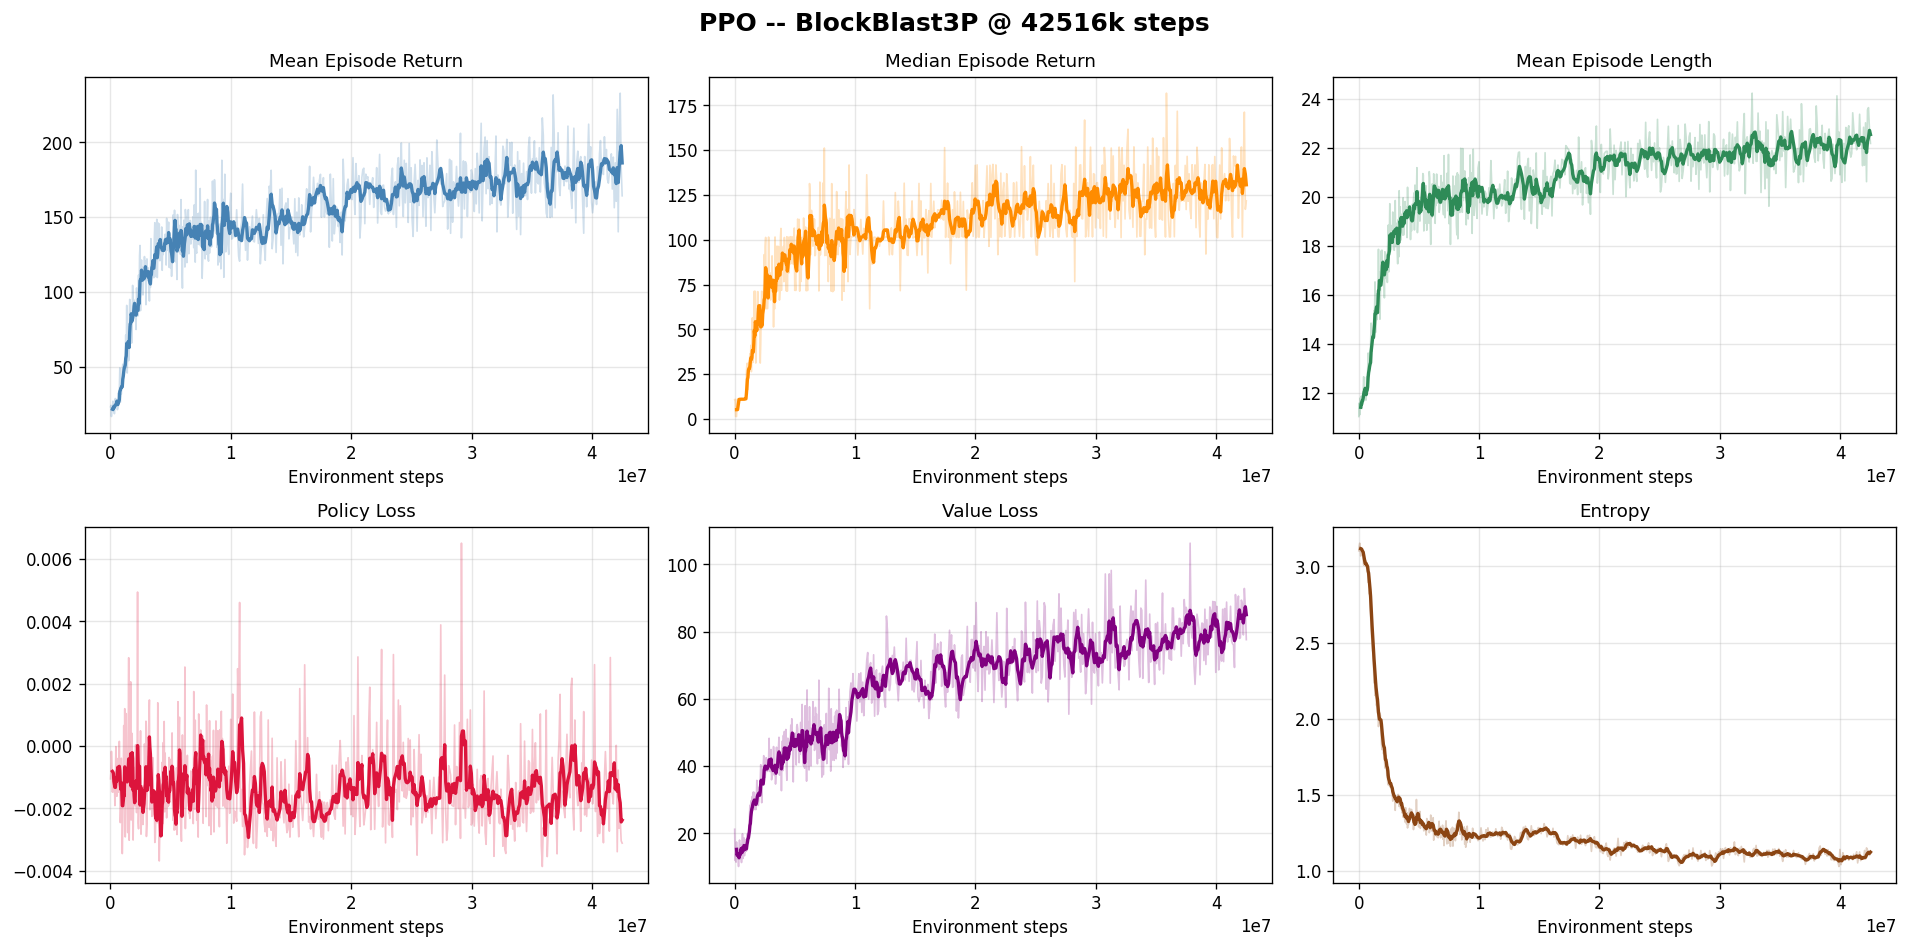

In [5]:
from IPython.display import Image
Image("../plots/ckpt_42516k_curves.png", width=900)

Effect of the value weight α (50 episodes per value): α = 0 is a pure 3-step
greedy search; α ∈ [0.1, 0.5] works best.

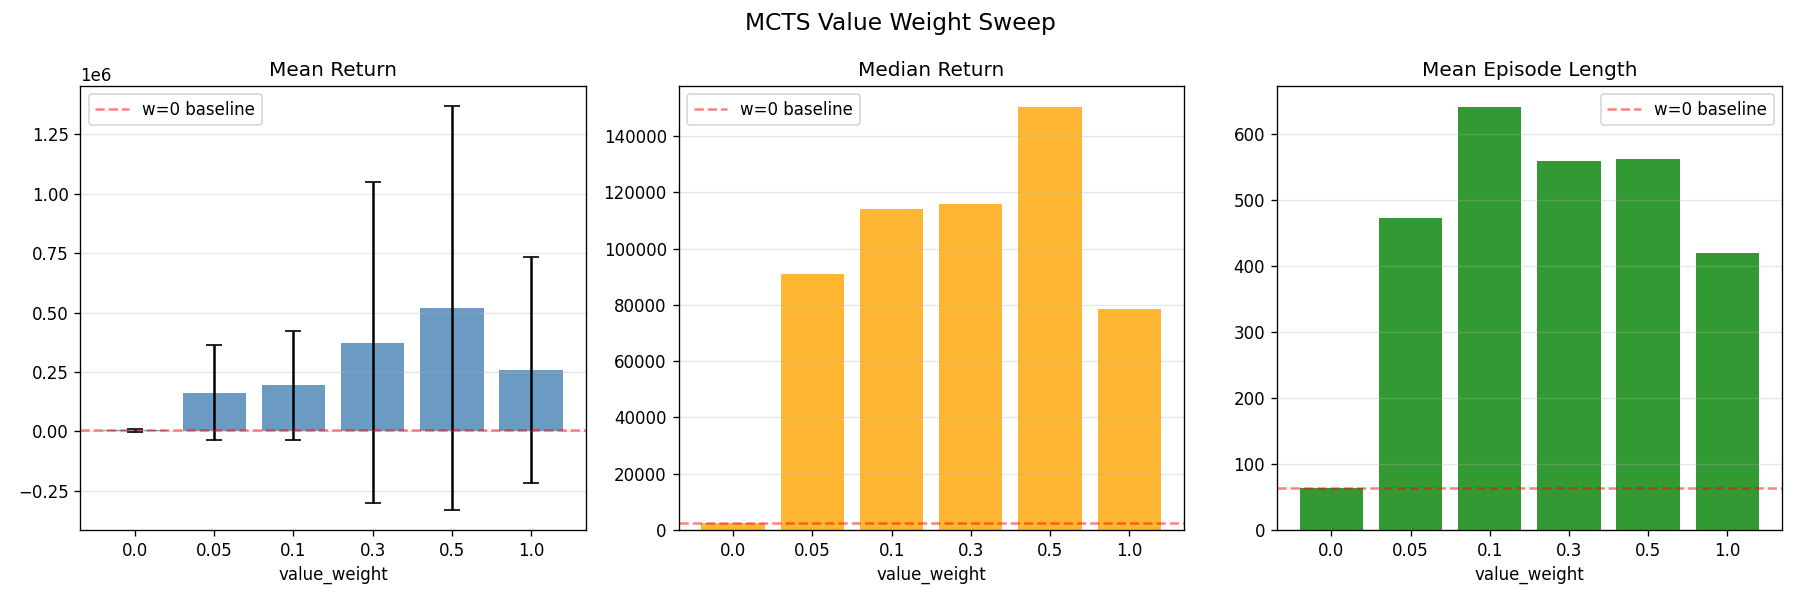

In [6]:
Image("../plots/value_weight_sweep.png", width=900)

Final comparison (log scale): executing the whole planned triplet reaches a
mean return of ~451k and ~687 placements per game.

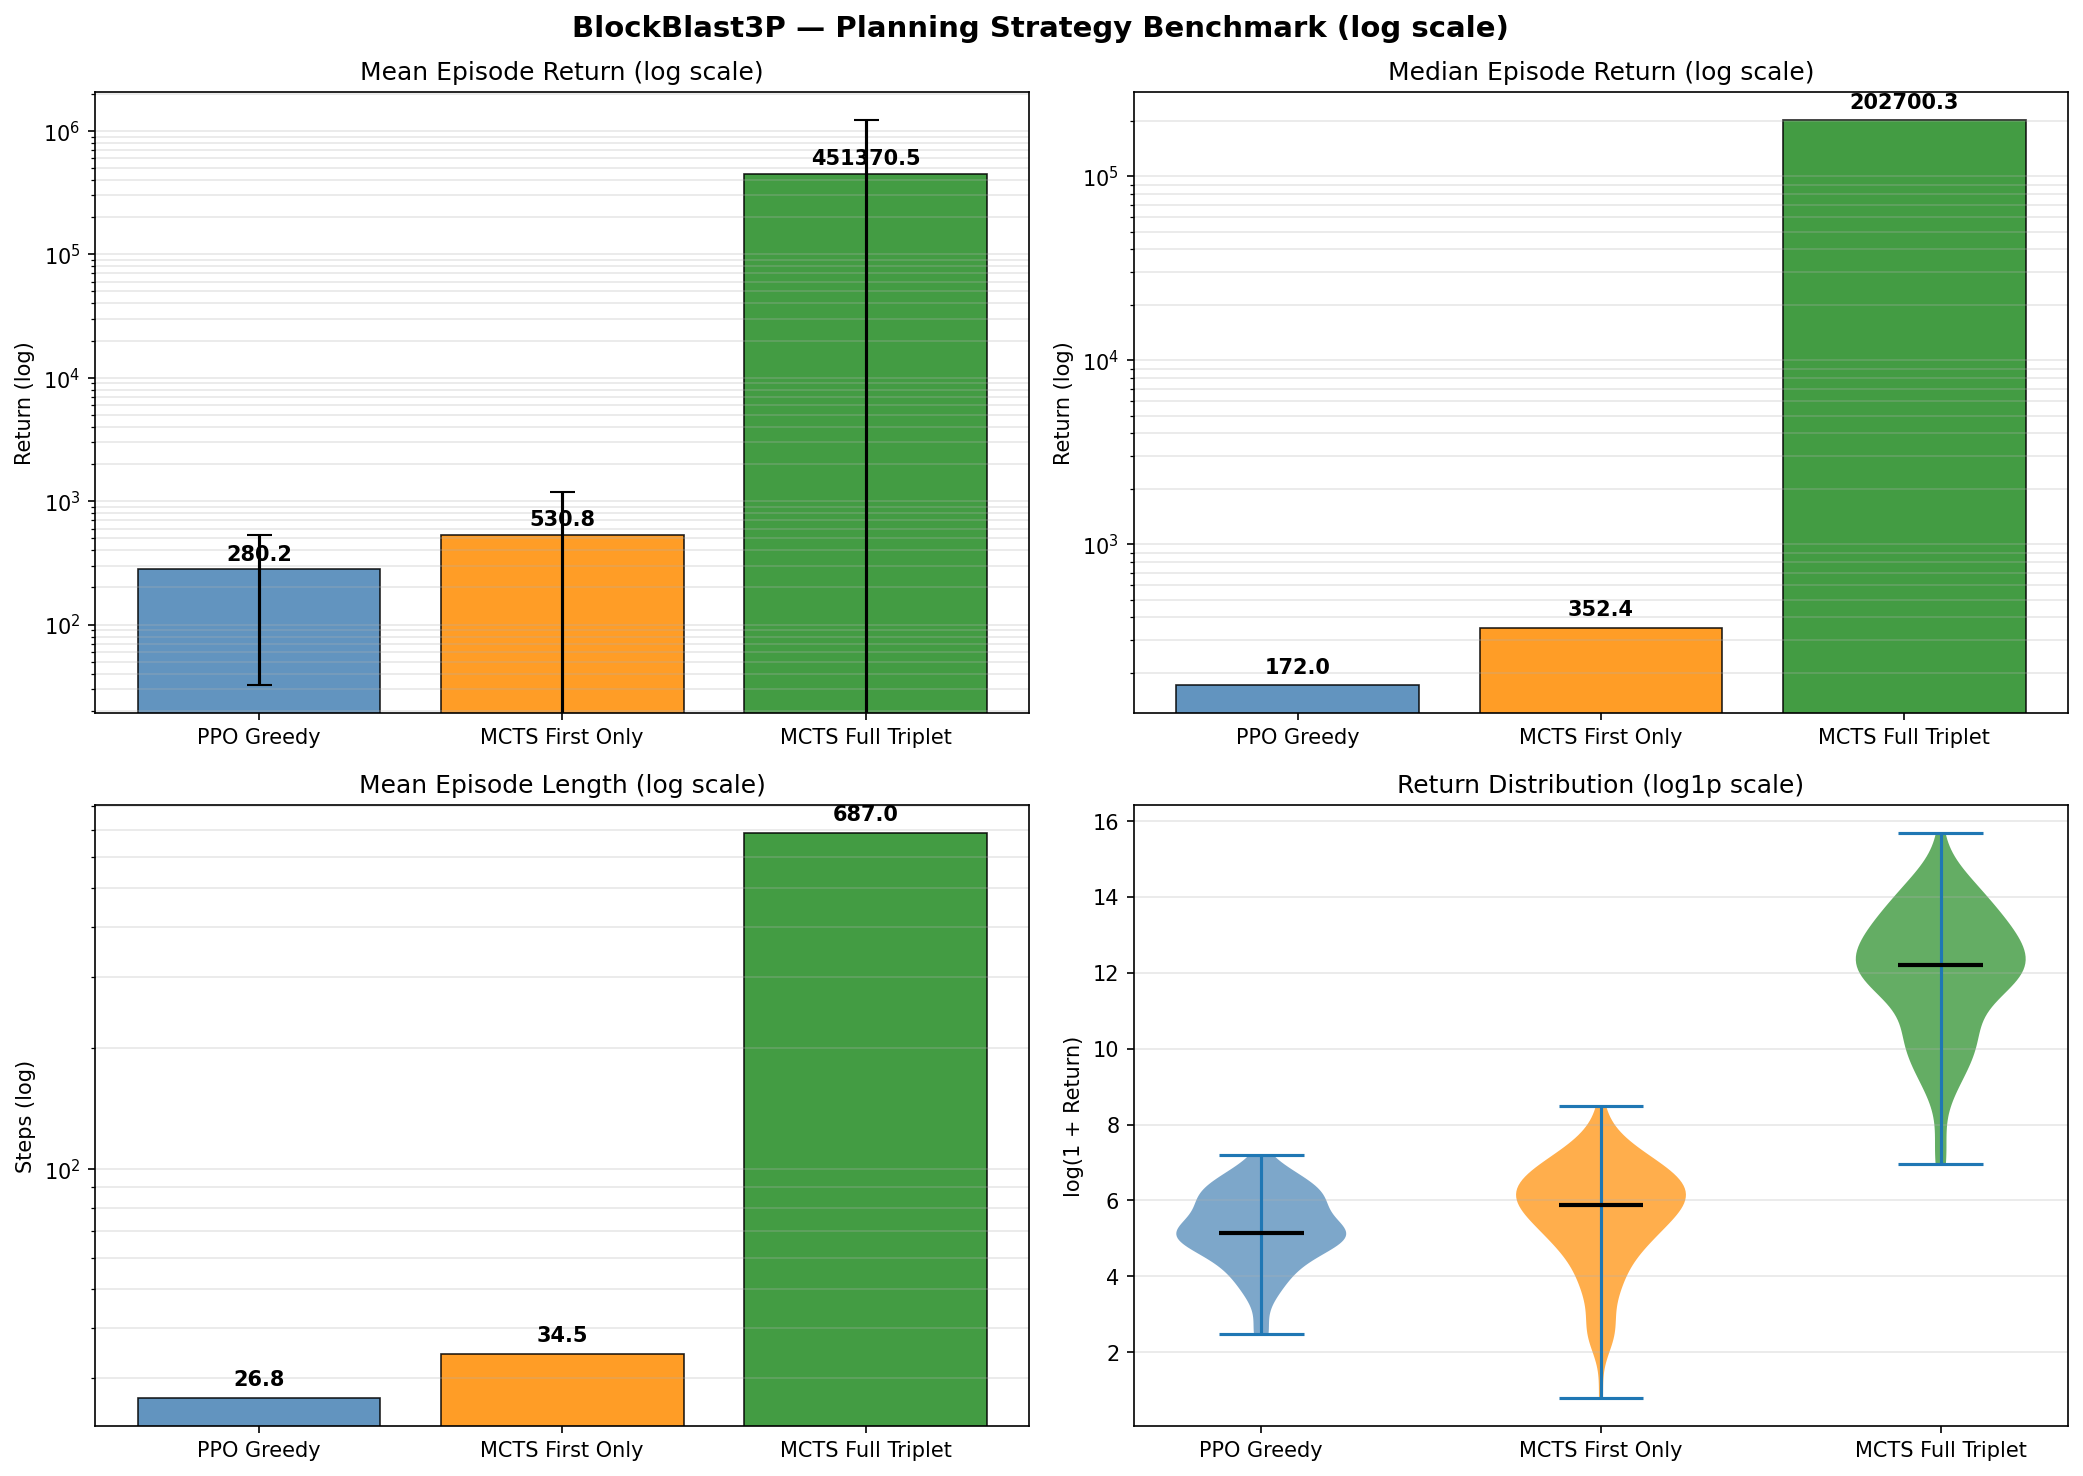

In [7]:
Image("../plots/benchmark_3p_log.png", width=700)